In [ ]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv('games.csv')
print(df)


                                Name Platform  Year_of_Release         Genre  \
0                         Wii Sports      Wii           2006.0        Sports   
1                  Super Mario Bros.      NES           1985.0      Platform   
2                     Mario Kart Wii      Wii           2008.0        Racing   
3                  Wii Sports Resort      Wii           2009.0        Sports   
4           Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3           2016.0        Action   
16711               LMA Manager 2007     X360           2006.0        Sports   
16712        Haitaka no Psychedelica      PSV           2016.0     Adventure   
16713               Spirits & Spells      GBA           2003.0      Platform   
16714            Winning Post 8 2016      PSV           2016.0    Simulation   

       NA_sales  EU_sales  JP_sales  Ot

In [3]:
#ETAPA 2

In [4]:

df.columns = df.columns.str.lower()
df.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [5]:
# Convertemos à partir do método lower os nomes de todas as colunas e tivemos que converter eles para um string pois estava retornando como um dtype object anteriormente


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [7]:
df['user_score']= df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df = df.dropna(subset= ['year_of_release'])
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


In [8]:
# Encontramos alguns valores ausentes em algumas colunas de dados. Na coluna user_score foi tratado como dado ausente e substituido por Nan pois não representa uma informação numérica válida.
# Na coluna year_of_release usamos o método dropna para retirar as linhas que continham valores ausentes para saber exatamente os anos do que estamos procurando.
#Optei por não preencher os valores ausentes pois pode conter falta de registro ou informaçoes dos jogos.


In [9]:
df['total_sales']= df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
df['total_sales']

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: total_sales, Length: 16446, dtype: float64

In [10]:
#ETAPA 3

In [11]:
games_per_year = df['year_of_release'].value_counts().sort_index()
games_per_year.head(20)

1980.0      9
1981.0     46
1982.0     36
1983.0     17
1984.0     14
1985.0     14
1986.0     21
1987.0     16
1988.0     15
1989.0     17
1990.0     16
1991.0     41
1992.0     43
1993.0     62
1994.0    121
1995.0    219
1996.0    263
1997.0    289
1998.0    379
1999.0    338
Name: year_of_release, dtype: int64

In [12]:
# Os jogos tiveram um crescimento maior à partir de 1995, antes desse período tinham poucos lançamentos de jogos por ano.
# À partir de 1995 em diante conseguimos analisar um crescimento de lançamentos de jogos por ano.

In [13]:
platform_sales= df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.head(10)


platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

<AxesSubplot:xlabel='year_of_release'>

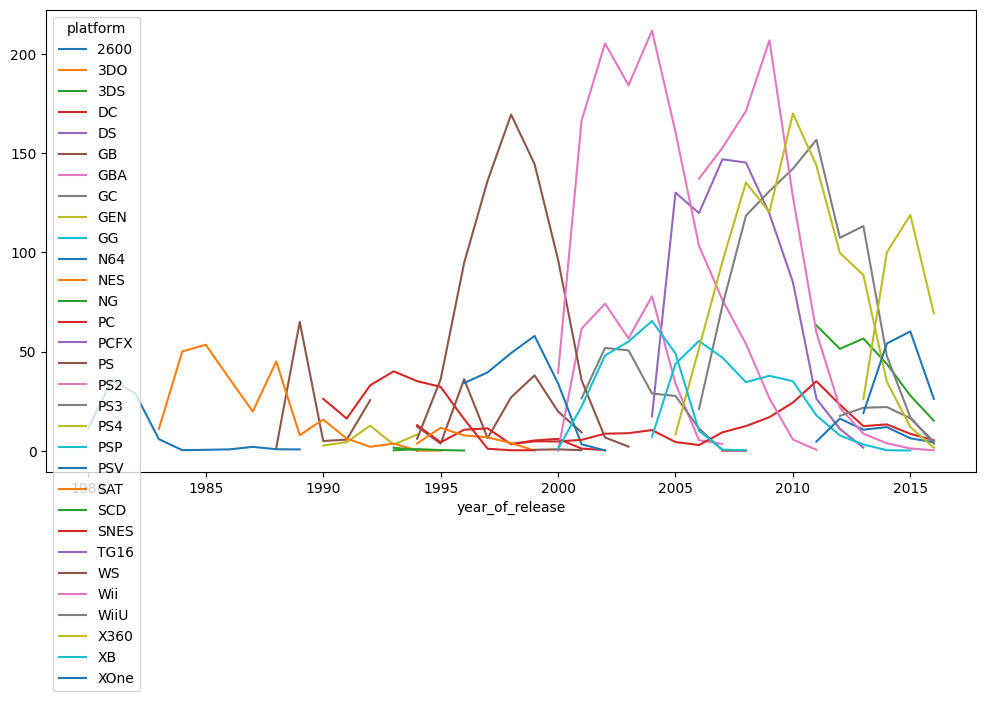

In [14]:
platform_year= df.pivot_table(
    index= 'year_of_release',
    columns= 'platform',
    values= 'total_sales',
    aggfunc= 'sum'
)
platform_year.plot(figsize=(12,6))

In [15]:
# As plataformas que tiveram maior número de vendas foram PS2, X360, PS3 e Wii.
# Verificamos pelo gráfico que grande parte das plataformas começam com vendas bem consolidadas até 5 anos, depois disso começam a declinar isso se dá provalvelmente pela criação de novos consoles mais modernos.
# Em média de 5 em 5 anos aparecem novas plataformas e consequentemente nesse mesmo tempo uma plataforma desaparece.

In [16]:
df_recent = df[df['year_of_release']>=2010]
df_recent

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
14,Kinect Adventures!,X360,2010.0,Misc,15.00,4.89,0.24,1.69,61.0,6.3,E,21.82
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
27,Pokemon Black/Pokemon White,DS,2010.0,Role-Playing,5.51,3.17,5.65,0.80,NaN,NaN,NaN,15.13
29,Call of Duty: Modern Warfare 3,X360,2011.0,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16707,Aiyoku no Eustia,PSV,2014.0,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


In [17]:
#Escolhemos aqui as plataformas de 2010, uma crescente que tivemos foram jogos do console X360, PS3 e DS. 
# Ainda no arquivo podemos ver o quanto a plataforma PSV caiu para quase zero vendas nesse mesmo período.

<AxesSubplot:title={'center':'total_sales'}, xlabel='platform'>

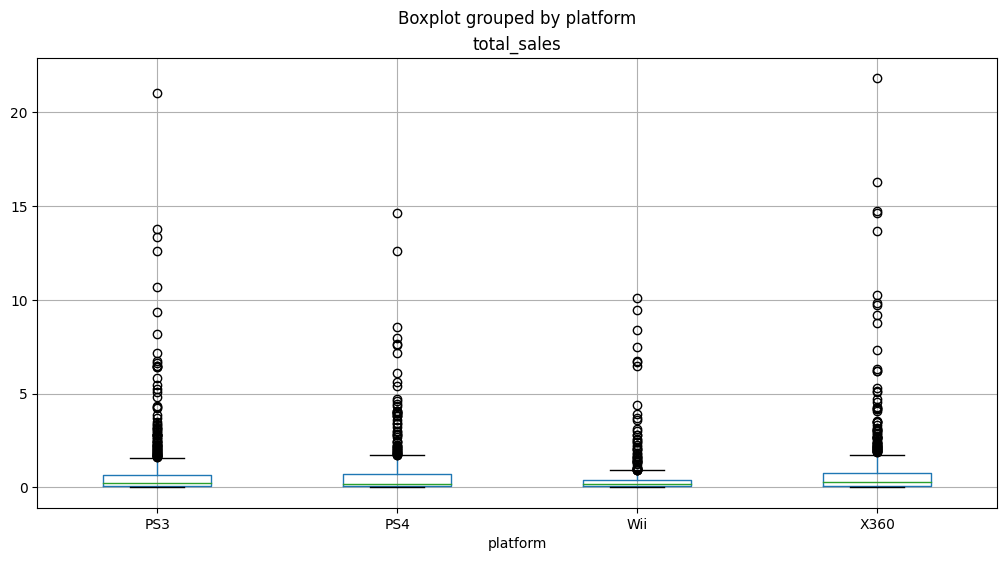

In [18]:
platform = ['PS4', 'PS3', 'X360', 'Wii']
df_filtered= df_recent[df_recent['platform'].isin(platform)]
df_filtered.boxplot(
    column= 'total_sales',
    by= 'platform', 
    figsize= (12,6)
)

In [19]:
# Às vendas por plataformas são bem parecidas no geral, mas PS3 e X360 apresentam valores maiores em questão de vendas.
# Da para perceber também casos isolados de alguns títulos de jogos com vendas bem mais altas como Grand Theft Auto V por exemplo, vendido em ambas plataformas e com muitos consumidores.
# Para a criação do diagrama de caixa eu selecionei os 4 consoles que mais vendiam jogos para o gráfico não ficar bagunçado para apresentar todos os consoles de uma vez.

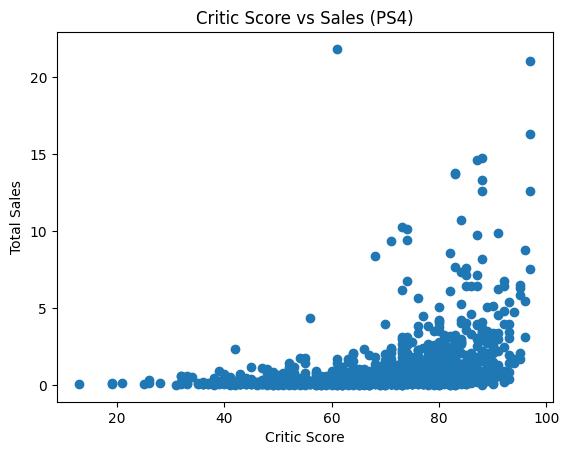

,critic_score,total_sales
critic_score,1.000000,0.363997
total_sales,0.363997,1.000000


In [20]:
plt.scatter(
    df_filtered['critic_score'],
    df_filtered['total_sales']
)
plt.xlabel('Critic Score')
plt.ylabel('Total Sales')
plt.title('Critic Score vs Sales (PS4)')
plt.show()
df_filtered[['critic_score', 'total_sales']].corr()

In [21]:
# A correlação entre a nota da crítica com o total vendidos na plataforma PS4 ficou em torno de 0.36, o que indica uma relação fraca.
# Percebemos também que jogos com notas altas acabam vendendo mais mas que não acontece sempre.

In [22]:
#Os mesmos jogos podem vender bem em diferentes plataformas, pegamos como exemplo o Grand Theft Auto V que é um dos campeões de vendas tanto para PS3 quanto para X360.

In [23]:
df_recent.groupby('genre')['total_sales'].sum()


genre
Action          673.09
Adventure        61.00
Fighting         81.59
Misc            234.56
Platform        119.72
Puzzle           20.60
Racing          122.68
Role-Playing    315.28
Shooter         479.74
Simulation       71.75
Sports          328.39
Strategy         35.84
Name: total_sales, dtype: float64

In [24]:
# Verificamos que gênero de jogos como Action, Shooter, Sports e Role-Playing são os gêneros que tem maior número de vendas e são muito mais lucrativos comparado a outros estilos de gênero.

In [25]:
# ETAPA 4

In [26]:
df_recent.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)



platform
X360    334.18
PS3     229.25
Wii     121.20
PS4     108.74
XOne     93.12
Name: na_sales, dtype: float64

In [27]:
df_recent.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)

platform
PS3     213.60
X360    163.41
PS4     141.09
PC       68.82
Wii      65.91
Name: eu_sales, dtype: float64

In [28]:
df_recent.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

platform
3DS    100.62
PS3     59.26
PSP     42.20
DS      27.90
PSV     21.84
Name: jp_sales, dtype: float64

In [29]:
# Verificamos com o método sort_values as 5 plataformas principais em cada região como Japão, América do Norte e Europa.
# Na américa do norte o console mais vendido é o X360.
# Na europa o console mais vendido é o PS3.
# No Japão o console mais vendido é o 3DS.

In [30]:
top_5_na = df_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_5_na

genre
Action          290.64
Shooter         237.47
Sports          156.81
Misc            123.80
Role-Playing    112.05
Name: na_sales, dtype: float64

In [31]:
top_5_eu = df_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_5_eu

genre
Action          233.63
Shooter         171.45
Sports          116.84
Role-Playing     75.48
Misc             66.09
Name: eu_sales, dtype: float64

In [32]:
top_5_jp = df_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
top_5_jp

genre
Role-Playing    103.54
Action           72.20
Misc             24.29
Platform         15.81
Adventure        15.67
Name: jp_sales, dtype: float64

In [33]:
# Em cada local predonima um tipo de gênero sendo que na Europa e na América do Norte o predominante é o gênero Action e Shooter.
# No Japão o gênero predominante é o Role-Playing, isso mostra a diferença de estilos de gêneros de país em país.

In [34]:
df_recent.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head(5)

rating
M       382.22
E       271.15
T       160.81
E10+    159.38
EC        1.13
Name: na_sales, dtype: float64

In [35]:
df_recent.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head(5)

rating
M       292.04
E       197.34
T       113.08
E10+     99.28
RP        0.03
Name: eu_sales, dtype: float64

In [36]:
df_recent.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head(5)

rating
E       47.87
T       42.11
M       30.45
E10+    13.22
EC       0.00
Name: jp_sales, dtype: float64

In [37]:
# As classificações do ESBR parecem influenciar as vendas de forma diferente em cada região.
# Na América do Norte e na Europa os jogos classificados com M e E concentram maiores quantidades de vendas.
# No Japão os jogos classificados como E e T aparecem na frente.
#Isso mostra o consumo diferente de cada região do mundo que analisamos.

In [38]:
# ETAPA 5

In [39]:
xone= df_recent[df_recent['platform']== 'XOne']['user_score']
xone = xone.dropna()
xone

165      7.9
179      5.4
242      6.4
270      6.2
373      4.1
        ... 
16544    6.8
16597    6.0
16630    8.2
16643    6.6
16660    6.7
Name: user_score, Length: 182, dtype: float64

In [40]:
pc= df_recent[df_recent['platform']== 'PC']['user_score']
pc= pc.dropna()
pc

192      4.0
218      8.2
313      8.1
458      3.9
480      5.9
        ... 
16518    1.4
16584    7.9
16692    7.6
16696    5.8
16702    7.2
Name: user_score, Length: 374, dtype: float64

In [41]:
alpha= 0.05

In [42]:
results = stats.ttest_ind(xone, pc)
print(results.pvalue)

0.980998110649032


In [43]:

if results.pvalue < alpha:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")


Não rejeitamos H0


In [44]:
action= df_recent[df_recent['genre']== 'Action']['user_score'].dropna()
sports= df_recent[df_recent['genre']== 'Sports']['user_score'].dropna()
print(action)
print(sports)

16       8.2
23       8.1
42       8.3
81       6.6
118      8.3
        ... 
16597    6.0
16652    8.5
16654    5.1
16660    6.7
16692    7.6
Name: user_score, Length: 779, dtype: float64
77       4.3
94       5.0
126      4.3
141      7.4
143      5.7
        ... 
16146    6.9
16230    5.5
16450    4.5
16518    1.4
16643    6.6
Name: user_score, Length: 315, dtype: float64


In [46]:
results2= stats.ttest_ind(action, sports)
print(results2.pvalue)
if results2.pvalue < alpha:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")


7.839124224330309e-19
Rejeitamos H0


In [47]:
# A hipótese nula considera que as médias são iguais, enquanto a alternativa considera que são diferentes.
# Foi utilizado um nível de significância de 0.05, por ser um padrão em testes de estatísticas.

In [ ]:
# ETAPA 6

In [ ]:
#Conclusão Geral
# Nesse projeto foram analisados dados de vendas de jogos para entender padrões entre plataformas, gêneros e regiões.
# Foi possível verificar que as preferências de cada diferem em cada tipo de região, com diferenças na plataforma e até mesmo os jogos mais vendidos de acordo com cada uma das regiões.
# Foi identificado também que a classificação indicativa (ESRB) influencia diretamente no comportamento de vendas de acordo com cada região.
# Nos testes estatísticos verificamos que não há uma diferença significativa entre as avaliações dos usuários para XOne e PC. Porém foi encontrada uma diferença significativa entre os gêneros Action e Sports.
# A análise mostra que fatores como região, tipo de jogo e perfil de público influenciam diretamente no número total de vendas de jogos.
